<a href="https://colab.research.google.com/github/ZethRodaje/Phishing-Website-Detection-Using-Machine-Learning/blob/main/Phishing_Website_Detection_Using_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Phishing Website Detection Using Machine Learning**

**0. Setup and Config**

In [ ]:
!pip install -U scikit-learn

In [ ]:
import sklearn, sys
print(sys.version, sklearn.__version__)

3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0] 1.9.1


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math
import re
import joblib
from urllib.parse import urlparse

from sklearn.base import clone
from sklearn.model_selection import (train_test_split, StratifiedKFold, StratifiedGroupKFold, cross_validate,
                                     cross_val_predict, RandomizedSearchCV, GridSearchCV)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.dummy import DummyClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, make_scorer, roc_auc_score, average_precision_score)

RANDOM_STATE = 42
IP_RE = re.compile(r"^(\d{1,3}\.){3}\d{1,3}$")

**1. Load and Inspect**

In [ ]:
df = pd.read_csv("phishing_features.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (160064, 13)


,url,label,url_length,num_dots,has_https,has_ip,num_subdirs,num_params,suspicious_words,tld,special_char_count,digits_count,entropy
0,http://forum.uk.securebankinggroup.com/107519/...,1,89,3,0,0,5,0,2,com,4,29,4.792985
1,http://b45042.com/fish/29,1,25,1,0,0,4,0,0,com,0,7,4.003856
2,http://bet73018.com/lottery/99,1,30,1,0,0,4,0,0,com,0,7,4.053236
3,https://logiin--metsa-autho.webflow.io/,1,39,2,1,0,3,0,0,io,3,0,4.150411
4,https://mettamasklogiiann.webflow.io/,1,37,2,1,0,3,0,0,io,0,0,4.100817


In [ ]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nLabel distribution:")
print(df["label"].value_counts())
print(df["label"].value_counts(normalize=True) * 100)

Missing values:
url                     0
label                   0
url_length              0
num_dots                0
has_https               0
has_ip                  0
num_subdirs             0
num_params              0
suspicious_words        0
tld                   821
special_char_count      0
digits_count            0
entropy                 0
dtype: int64

Duplicate rows: 0

Label distribution:
label
1    159244
0       820
Name: count, dtype: int64
label
1    99.487705
0     0.512295
Name: proportion, dtype: float64


**2. Clean the Data**

In [ ]:
before = len(df)
df = df.drop_duplicates()
after = len(df)
print(f"Duplicates removed: {before - after} ({before} -> {after} rows)")

# The raw 'tld' column is unreliable: it is missing for all 820 benign rows and holds junk
# values (like "202") for IP hosts. It is rebuilt from the host in section 3.5, so this
# fill is only a placeholder.
df["tld"] = df["tld"].fillna("unknown")
print("Remaining missing values:", df.isnull().sum().sum())

Duplicates removed: 0 (160064 -> 160064 rows)
Remaining missing values: 0


**3. Check for Data Leakage**

In [ ]:
numeric_features = ["url_length", "num_dots", "has_https", "has_ip", "num_subdirs",
                     "num_params", "suspicious_words", "special_char_count", "digits_count", "entropy"]

print("Feature correlation with label:")
print(df[numeric_features + ["label"]].corr()["label"].sort_values(key=abs, ascending=False))

print("\nChecking each feature for a perfectly-separating value range:")
for col in numeric_features:
    benign_vals = df.loc[df["label"] == 0, col]
    phishing_vals = df.loc[df["label"] == 1, col]
    if benign_vals.max() < phishing_vals.min() or phishing_vals.max() < benign_vals.min():
        print(f"  PERFECT SEPARATION on '{col}': benign [{benign_vals.min()}, {benign_vals.max()}], "
              f"phishing [{phishing_vals.min()}, {phishing_vals.max()}]")

Feature correlation with label:
label                 1.000000
num_subdirs           0.141735
entropy               0.133363
num_dots              0.125898
has_ip                0.069704
has_https             0.062848
digits_count          0.047991
url_length            0.028927
special_char_count    0.028911
num_params            0.016988
suspicious_words      0.008595
Name: label, dtype: float64

Checking each feature for a perfectly-separating value range:
  PERFECT SEPARATION on 'num_subdirs': benign [0, 0], phishing [2, 104]


**Digging deeper: why does num_subdirs show zero overlap?**

A feature that separates the classes perfectly is a warning sign. It is worth checking why before simply dropping it.

In [ ]:
print("Does any benign URL have a scheme (://)?", df.loc[df.label == 0, "url"].str.contains("://").any())
print("Do all phishing URLs have a scheme (://)?", df.loc[df.label == 1, "url"].str.contains("://").all())
print()
print("num_subdirs by class:")
print(df.groupby("label")["num_subdirs"].describe()[["mean", "std", "min", "max"]])
print()
print("Sample benign URLs (note: bare domains, no scheme, no path):")
print(df.loc[df.label == 0, "url"].sample(8, random_state=1).tolist())

Does any benign URL have a scheme (://)? False
Do all phishing URLs have a scheme (://)? True

num_subdirs by class:
           mean       std  min    max
label                                
0      0.000000  0.000000  0.0    0.0
1      4.149695  2.074399  2.0  104.0

Sample benign URLs (note: bare domains, no scheme, no path):
['shopify.com', 'trustedsite65.org', 'adobe.com', 'kaist.ac.kr', 'gov.cn', 'leetcode.com', 'atlassian.com', 'kaggle.com']


**Root cause found:** none of the 820 benign URLs carry a scheme (http:// or https://). They are bare domains like shopify.com, adobe.com and kaggle.com. This collection artifact explains more than just num_subdirs. has_https, num_params and suspicious_words do not measure phishing behavior for these rows. They only show which source list a URL came from (a full phishing feed URL or a bare-domain benign list). A model trained on them learns a shortcut instead of a real signal, even for features that did not show up as perfectly separating in the simple range check above.

**3.5. Normalize URLs and Rebuild Features From the Host**

**Note on the tld column:** In the raw data, tld is missing for 820 of the 821 rows with a missing value, and all 820 are benign. It also holds junk values for IP hosts (for example "202"). Used as is, it would let a model separate the classes by which source list a row came from. The column is therefore rebuilt from the host name: IP hosts become "ip_address" and every other host gets its last label (such as "com" or "org"). The result is turned into a frequency feature (tld_freq) using training data only.

Every URL is reduced to its host name. The host is lowercased and a leading "www." is removed. None of the benign hosts in this dataset start with "www.", so leaving it in teaches the model that "www." means phishing. The feature set also includes extra host-name features (label lengths, digit runs, ratios, and a suspicious-word flag) alongside the original ones.

In [ ]:
SUSP_WORDS = ["login", "signin", "secure", "verify", "account", "update", "banking", "confirm",
              "webscr", "password", "support", "billing", "recover", "unlock", "alert", "suspend"]

def normalize_host(u):
    u = u.strip()
    if "://" not in u:
        u = "http://" + u  # benign rows have no scheme; the scheme itself is never used as a feature
    h = urlparse(u).netloc.split(":")[0].lower()  # strip port, keep bare host
    if h.startswith("www.") and h.count(".") >= 2:
        h = h[4:]  # drop a leading www. so it cannot act as a dataset shortcut
    return h

def shannon_entropy(s):
    if not s:
        return 0.0
    probs = [s.count(c) / len(s) for c in set(s)]
    return -sum(p * math.log2(p) for p in probs)

def get_tld(host):
    if IP_RE.match(host):
        return "ip_address"
    parts = host.split(".")
    return parts[-1] if len(parts) >= 2 else "unknown"

def host_features(h):
    is_ip = bool(IP_RE.match(h))
    labels = h.split(".") if h else [""]
    n = max(len(h), 1)
    n_digits = len(re.findall(r"\d", h))
    n_hyphens = h.count("-")
    letters = re.findall(r"[a-z]", h)
    vowels = [ch for ch in letters if ch in "aeiou"]
    digit_runs = re.findall(r"\d+", h)
    return {
        "url_length": len(h),
        "num_dots": h.count("."),
        "has_ip": int(is_ip),
        "digits_count": n_digits,
        "num_hyphens": n_hyphens,
        "subdomain_count": 0 if is_ip else max(len(labels) - 2, 0),
        "entropy": shannon_entropy(h),
        "num_labels": len(labels),
        "longest_label": max(len(x) for x in labels),
        "longest_digit_run": max((len(x) for x in digit_runs), default=0),
        "digit_ratio": n_digits / n,
        "hyphen_ratio": n_hyphens / n,
        "vowel_ratio": len(vowels) / len(letters) if letters else 0.0,
        "has_susp_word": int(any(w in h for w in SUSP_WORDS)),
        "tld": get_tld(h),
    }

raw_www = df["url"].str.lower().str.contains(r"^(?:\w+://)?www\.")
print("Share of URLs starting with www. BEFORE stripping, by class:")
print(raw_www.groupby(df["label"]).mean().round(4))

df["host"] = df["url"].map(normalize_host)
feats = pd.DataFrame([host_features(h) for h in df["host"]], index=df.index)
for col in feats.columns:
    df[col] = feats[col]

# Dropped entirely: has_https (unmeasurable for benign source), num_subdirs / num_params /
# suspicious_words (path-only features; benign URLs have no path to measure),
# special_char_count (importance was zero in the previous run)

feature_cols = [c for c in feats.columns if c != "tld"]

print("\nFeature means by class after normalization:")
print(df.groupby("label")[feature_cols].mean().T)

Share of URLs starting with www. BEFORE stripping, by class:
label
0    0.0000
1    0.0169
Name: url, dtype: float64

Feature means by class after normalization:
label                      0          1
url_length         14.078049  16.203204
num_dots            1.035366   2.365088
has_ip              0.000000   0.487296
digits_count        1.086585   5.994380
num_hyphens         0.004878   0.237773
subdomain_count     0.035366   0.390495
entropy             3.355376   3.014228
num_labels          2.035366   3.365088
longest_label      10.020732   6.939376
longest_digit_run   1.086585   1.933297
digit_ratio         0.065943   0.414221
hyphen_ratio        0.000353   0.011524
vowel_ratio         0.381350   0.177083
has_susp_word       0.000000   0.011398


---

After normalization, url_length is a host measurement for both classes, so benign hosts are no longer artificially short next to phishing URLs that include a path. The remaining differences (phishing hosts have more digits, more hyphens and more subdomains) reflect genuine domain naming patterns, not collection artifacts.

**3.6. Re-run the Leakage Check on the Normalized Features**

In [ ]:
print("Checking each normalized feature for a perfectly-separating value range:")
found = False
for col in feature_cols:
    benign_vals = df.loc[df["label"] == 0, col]
    phishing_vals = df.loc[df["label"] == 1, col]
    if benign_vals.max() < phishing_vals.min() or phishing_vals.max() < benign_vals.min():
        found = True
        print(f"  PERFECT SEPARATION on '{col}'")
if not found:
    print("  None found. Features now overlap between classes as expected.")

Checking each normalized feature for a perfectly-separating value range:
  None found. Features now overlap between classes as expected.


**4. Finalize the Feature Set**

In [ ]:
X = df[feature_cols + ["tld"]].copy()
y = df["label"]

print("Final input features (before tld encoding):", X.columns.tolist())
print("\nTarget distribution:")
print(y.value_counts())


Final input features (before tld encoding): ['url_length', 'num_dots', 'has_ip', 'digits_count', 'num_hyphens', 'subdomain_count', 'entropy', 'num_labels', 'longest_label', 'longest_digit_run', 'digit_ratio', 'hyphen_ratio', 'vowel_ratio', 'has_susp_word', 'tld']

Target distribution:
label
1    159244
0       820
Name: count, dtype: int64


**5. Train/Test Split (Stratifiedand Grouped by Domain)**

Rows that share the same registered domain (for example several phishing URLs on the same site) are kept together, so a domain never appears in both the training and the test set. A plain random split lets near-duplicate hosts leak across the split and makes scores look better than they are. The leak that a random split would cause is printed first for comparison.

In [ ]:
def base_domain(h):
    if IP_RE.match(h):
        return h
    parts = h.split(".")
    if len(parts) >= 3 and len(parts[-1]) == 2 and parts[-2] in {"co", "com", "org", "net", "gov", "edu", "ac", "or", "ne", "go"}:
        return ".".join(parts[-3:])  # e.g. example.co.uk
    return ".".join(parts[-2:])

groups = df["host"].map(base_domain)
print("Unique base domains:", groups.nunique(), "of", len(df), "rows")

# how much a plain random split would leak
rand_train, rand_test = train_test_split(X.index, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
leak = groups.loc[rand_test].isin(set(groups.loc[rand_train]))
print("\nRandom split: share of test rows whose domain also appears in training, by class:")
print(leak.groupby(y.loc[rand_test]).mean().round(4))

# grouped split: about 20% of rows for testing, no domain shared between train and test
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
train_pos, test_pos = next(sgkf.split(X, y, groups))
train_idx, test_idx = X.index[train_pos], X.index[test_pos]
x_train, x_test = X.loc[train_idx], X.loc[test_idx]
y_train, y_test = y.loc[train_idx], y.loc[test_idx]
g_train = groups.loc[train_idx]
assert set(g_train).isdisjoint(set(groups.loc[test_idx])), "domain shared between train and test"

# Fit tld frequency encoding on the TRAINING set only, then apply to both. This avoids leaking
# any test-set information into the encoding (a TLD's frequency must come from training data alone)
tld_freq_map = x_train["tld"].value_counts(normalize=True)
x_train = x_train.assign(tld_freq=x_train["tld"].map(tld_freq_map).fillna(0)).drop(columns=["tld"])
x_test = x_test.assign(tld_freq=x_test["tld"].map(tld_freq_map).fillna(0)).drop(columns=["tld"])

print("\nGrouped split, no shared domains between train and test.")
print("Training set shape:", x_train.shape)
print("Testing set shape:", x_test.shape)
print("Train class counts:", y_train.value_counts().to_dict())
print("Test class counts:", y_test.value_counts().to_dict())

Unique base domains: 32827 of 160064 rows

Random split: share of test rows whose domain also appears in training, by class:
label
0    0.0427
1    0.8825
Name: host, dtype: float64

Grouped split, no shared domains between train and test.
Training set shape: (128051, 15)
Testing set shape: (32013, 15)
Train class counts: {1: 127395, 0: 656}
Test class counts: {1: 31849, 0: 164}


**6. Handle the Class Imbalance**

Only 820 of 160,064 rows are benign (about 0.5%). The initial training run undersampled the phishing class down to a 3:1 ratio, which threw away most of the phishing data. Here every training row is kept and the imbalance is handled with **class weights** instead (no synthetic data, no discarded rows). The test set is left untouched until the final evaluation in section 10.

In [ ]:
cv5 = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def benign_pr_auc(est, X, y):
    # threshold-independent: how well the model ranks benign sites above phishing ones
    return average_precision_score(1 - np.asarray(y), est.predict_proba(X)[:, 0])

scoring = {
    "benign_pr_auc": benign_pr_auc,
    "roc_auc": "roc_auc",
    "macro_f1": "f1_macro",
    "balanced_acc": "balanced_accuracy",
    "benign_recall": make_scorer(recall_score, pos_label=0),
    "phishing_recall": make_scorer(recall_score, pos_label=1),
}

print("Training class balance:")
print(y_train.value_counts())

Training class balance:
label
1    127395
0       656
Name: count, dtype: int64


**7. Train and Compare Candidate Models (Cross-Validation on Training Data Only)**

All candidates are scored with stratified, domain-grouped 5-fold cross-validation on the training set (g_train holds each row's domain). The test set is not used for any model choice. Naive Bayes uses equal class priors since it has no class weight option. Models are ranked by **benign PR-AUC**, which does not depend on the decision threshold. That matters because the threshold is tuned later in section 9, and macro F1 at the default 0.5 threshold unfairly penalizes models that are well ranked but poorly calibrated (class weights shift the probabilities). Macro F1 and the recalls are still shown for reference.

In [ ]:
candidates = {
    "Dummy Baseline": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": make_pipeline(StandardScaler(),
                                         LogisticRegression(max_iter=1000, class_weight="balanced")),
    "Naive Bayes": GaussianNB(priors=[0.5, 0.5]),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", min_samples_leaf=5,
                                            random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight="balanced_subsample",
                                            min_samples_leaf=2, n_jobs=-1, random_state=RANDOM_STATE),
    "Gradient Boosting": HistGradientBoostingClassifier(class_weight="balanced", random_state=RANDOM_STATE),
}

cv_rows = {}
for name, model in candidates.items():
    res = cross_validate(model, x_train, y_train, cv=cv5, scoring=scoring, groups=g_train)
    cv_rows[name] = {k.replace("test_", ""): v.mean() for k, v in res.items() if k.startswith("test_")}
    print(f"done: {name}")

cv_table = pd.DataFrame(cv_rows).T.round(4)
cv_table

done: Dummy Baseline
done: Logistic Regression
done: Naive Bayes
done: Decision Tree
done: Random Forest
done: Gradient Boosting


,benign_pr_auc,roc_auc,macro_f1,balanced_acc,benign_recall,phishing_recall
Dummy Baseline,0.0051,0.5000,0.4987,0.5000,0.0000,1.0000
Logistic Regression,0.1526,0.9520,0.5020,0.9077,0.9543,0.8612
Naive Bayes,0.0744,0.9560,0.5106,0.9216,0.9634,0.8799
Decision Tree,0.5703,0.8949,0.5823,0.8747,0.8018,0.9476
Random Forest,0.6483,0.9804,0.6387,0.8596,0.7485,0.9708
Gradient Boosting,0.6684,0.9827,0.5948,0.9355,0.9162,0.9549


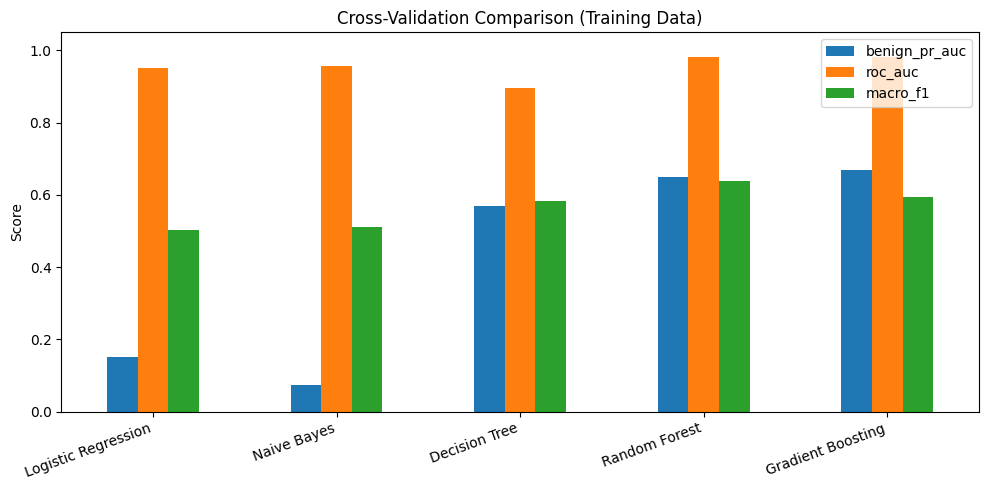

Best candidate by cross-validated benign PR-AUC: Gradient Boosting


In [ ]:
cv_table.drop(index="Dummy Baseline")[["benign_pr_auc", "roc_auc", "macro_f1"]].plot(
    kind="bar", figsize=(10, 5))
plt.title("Cross-Validation Comparison (Training Data)")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

leading = cv_table.drop(index="Dummy Baseline")["benign_pr_auc"].idxmax()
print(f"Best candidate by cross-validated benign PR-AUC: {leading}")

**8. Hyperparameter Tuning (Random Forest and Gradient Boosting)**

The two strongest tree-based candidates are each tuned with a randomized search on benign PR-AUC, using the training set only. Each best setting is refit on the full training set automatically. The model with the higher cross-validated benign PR-AUC becomes the final model, and its threshold is chosen in section 9.

In [ ]:
rf_search = GridSearchCV(
    RandomForestClassifier(class_weight="balanced_subsample", n_jobs=-1, random_state=RANDOM_STATE),
    param_grid={
        "n_estimators": [200, 300],
        "max_depth": [10, 20, None],
        "min_samples_leaf": [1, 2, 5, 10],
        "max_features": ["sqrt", 0.5],
        "max_samples": [0.3, 0.6],
    },
    scoring=benign_pr_auc, cv=cv5, refit=True, verbose=1,
)

hgb_search = RandomizedSearchCV(
    HistGradientBoostingClassifier(class_weight="balanced", random_state=RANDOM_STATE),
    param_distributions={
        "learning_rate": [0.03, 0.05, 0.1, 0.2],
        "max_iter": [100, 200, 300],
        "max_leaf_nodes": [15, 31, 63],
        "max_depth": [None, 6, 10],
        "min_samples_leaf": [10, 20, 50],
        "l2_regularization": [0.0, 0.1, 1.0],
    },
    n_iter=10, scoring=benign_pr_auc, cv=cv5, refit=True, random_state=RANDOM_STATE, verbose=1,
)

searches = {"Random Forest": rf_search, "Gradient Boosting": hgb_search}
for name, srch in searches.items():
    srch.fit(x_train, y_train, groups=g_train)
    print(f"\n{name}: best cross-validated benign PR-AUC = {srch.best_score_:.4f}")
    print("  best parameters:", srch.best_params_)

final_name = max(searches, key=lambda k: searches[k].best_score_)
final_model = searches[final_name].best_estimator_
print(f"\nFinal model: {final_name}")

Fitting 5 folds for each of 96 candidates, totalling 480 fits

Random Forest: best cross-validated benign PR-AUC = 0.6700
  best parameters: {'max_depth': None, 'max_features': 'sqrt', 'max_samples': 0.6, 'min_samples_leaf': 5, 'n_estimators': 200}
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Gradient Boosting: best cross-validated benign PR-AUC = 0.6869
  best parameters: {'min_samples_leaf': 20, 'max_leaf_nodes': 63, 'max_iter': 100, 'max_depth': 6, 'learning_rate': 0.2, 'l2_regularization': 0.0}

Final model: Gradient Boosting


**9. Choose the Decision Threshold (Training Data Only)**

The default rule (predict phishing when probability is at least 0.5) is not necessarily best when 99.5% of the data is phishing. Thresholds are evaluated on **out-of-fold** predictions from the training set, so the test set stays untouched.

Two choices are compared:
- **Macro F1 threshold:** the threshold with the best macro F1.
- **Goal threshold (used as the final one):** the threshold with the highest phishing recall among those that keep benign recall at or above a target. This controls false alarms on legitimate sites directly.

Macro F1 threshold : 0.02
Goal threshold     : 0.38  (benign recall >= 90%)

Out-of-fold results at the candidate thresholds:
           benign_recall  phishing_recall  macro_f1
threshold                                          
0.02              0.5290           0.9997    0.8323
0.38              0.9009           0.9544    0.5719
0.50              0.9146           0.9517    0.5685


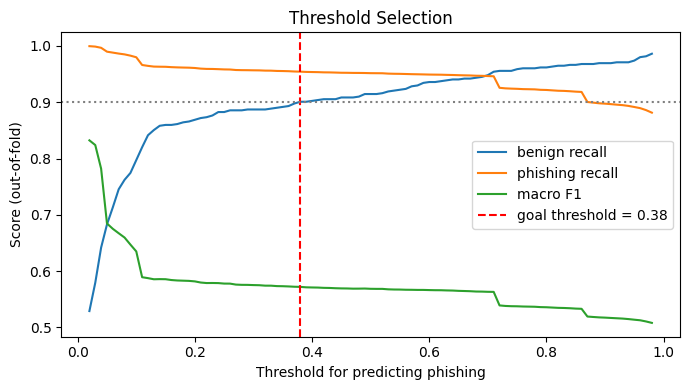

In [ ]:
TARGET_BENIGN_RECALL = 0.90   # change this to trade false alarms against missed phishing

oof_proba = cross_val_predict(clone(final_model), x_train, y_train, cv=cv5, groups=g_train, method="predict_proba")[:, 1]

thresholds = np.round(np.arange(0.02, 0.99, 0.01), 2)
rows = []
for t in thresholds:
    p = (oof_proba >= t).astype(int)
    rows.append({"threshold": t,
                 "benign_recall": recall_score(y_train, p, pos_label=0),
                 "phishing_recall": recall_score(y_train, p, pos_label=1),
                 "macro_f1": f1_score(y_train, p, average="macro")})
thr_table = pd.DataFrame(rows)

f1_threshold = float(thr_table.loc[thr_table["macro_f1"].idxmax(), "threshold"])

eligible = thr_table[thr_table["benign_recall"] >= TARGET_BENIGN_RECALL]
if len(eligible) > 0:
    pick = eligible.sort_values(["phishing_recall", "macro_f1"], ascending=False).iloc[0]
else:
    print(f"No threshold reaches benign recall {TARGET_BENIGN_RECALL:.0%}; falling back to the macro F1 threshold.")
    pick = thr_table.loc[thr_table["macro_f1"].idxmax()]
final_threshold = float(pick["threshold"])

print(f"Macro F1 threshold : {f1_threshold:.2f}")
print(f"Goal threshold     : {final_threshold:.2f}  (benign recall >= {TARGET_BENIGN_RECALL:.0%})")
print("\nOut-of-fold results at the candidate thresholds:")
print(thr_table.set_index("threshold").loc[sorted({0.5, round(f1_threshold, 2), round(final_threshold, 2)})].round(4))

plt.figure(figsize=(7, 4))
plt.plot(thr_table["threshold"], thr_table["benign_recall"], label="benign recall")
plt.plot(thr_table["threshold"], thr_table["phishing_recall"], label="phishing recall")
plt.plot(thr_table["threshold"], thr_table["macro_f1"], label="macro F1")
plt.axvline(final_threshold, color="red", linestyle="--", label=f"goal threshold = {final_threshold:.2f}")
plt.axhline(TARGET_BENIGN_RECALL, color="gray", linestyle=":")
plt.xlabel("Threshold for predicting phishing")
plt.ylabel("Score (out-of-fold)")
plt.title("Threshold Selection")
plt.legend()
plt.tight_layout()
plt.show()

**10. Final Evaluation on the Held-Out Test Set**

This is the only time the test set is used to score the finished model. The tuned model is compared with the dummy baseline and with the untuned Random Forest setup from the initial training run.

In [ ]:
def evaluate(name, y_true, preds):
    accuracy = accuracy_score(y_true, preds)
    precision = precision_score(y_true, preds, pos_label=1, zero_division=0)
    recall = recall_score(y_true, preds, pos_label=1)
    f1 = f1_score(y_true, preds, pos_label=1)
    macro_f1 = f1_score(y_true, preds, average="macro")

    cm = confusion_matrix(y_true, preds, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    benign_recall = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    print(f"\n=== {name} ===")
    print(f"Accuracy : {accuracy*100:.2f}%")
    print(f"Precision: {precision*100:.2f}%")
    print(f"Recall   : {recall*100:.2f}%")
    print(f"F1 Score : {f1*100:.2f}%  (phishing class only)")
    print(f"Macro F1 : {macro_f1*100:.2f}%  (both classes weighted equally)")
    print(f"False Positive Rate: {fpr*100:.2f}%")
    print(f"Benign Recall: {benign_recall*100:.2f}%")
    print(f"Confusion Matrix:\n{cm}")

    return {"Accuracy": accuracy, "Precision": precision, "Recall": recall, "F1 Score": f1,
            "Macro F1": macro_f1, "False Positive Rate": fpr, "Benign Recall": benign_recall}

# reference models
dummy = DummyClassifier(strategy="most_frequent").fit(x_train, y_train)
initial_rf = RandomForestClassifier(n_estimators=200, class_weight="balanced", n_jobs=-1,
                                    random_state=RANDOM_STATE).fit(x_train, y_train)

test_proba = final_model.predict_proba(x_test)[:, 1]

results = {
    "Dummy Baseline": evaluate("Dummy Baseline", y_test, dummy.predict(x_test)),
    "Initial Random Forest": evaluate("Initial Random Forest (untuned)", y_test, initial_rf.predict(x_test)),
    f"Tuned {final_name} (0.50)": evaluate(f"Tuned {final_name}, threshold 0.50", y_test, (test_proba >= 0.5).astype(int)),
    f"Tuned {final_name} (macro F1 thr {f1_threshold:.2f})": evaluate(
        f"Tuned {final_name}, macro F1 threshold {f1_threshold:.2f}", y_test, (test_proba >= f1_threshold).astype(int)),
    f"Tuned {final_name} (goal thr {final_threshold:.2f})": evaluate(
        f"Tuned {final_name}, goal threshold {final_threshold:.2f} (FINAL)", y_test, (test_proba >= final_threshold).astype(int)),
}

print(f"\nROC-AUC (tuned model)            : {roc_auc_score(y_test, test_proba):.4f}")
print(f"PR-AUC for the benign class      : {average_precision_score(1 - y_test, 1 - test_proba):.4f}")


=== Dummy Baseline ===
Accuracy : 99.49%
Precision: 99.49%
Recall   : 100.00%
F1 Score : 99.74%  (phishing class only)
Macro F1 : 49.87%  (both classes weighted equally)
False Positive Rate: 100.00%
Benign Recall: 0.00%
Confusion Matrix:
[[    0   164]
 [    0 31849]]

=== Initial Random Forest (untuned) ===
Accuracy : 98.71%
Precision: 99.90%
Recall   : 98.80%
F1 Score : 99.35%  (phishing class only)
Macro F1 : 69.14%  (both classes weighted equally)
False Positive Rate: 19.51%
Benign Recall: 80.49%
Confusion Matrix:
[[  132    32]
 [  382 31467]]

=== Tuned Gradient Boosting, threshold 0.50 ===
Accuracy : 97.37%
Precision: 99.95%
Recall   : 97.40%
F1 Score : 98.66%  (phishing class only)
Macro F1 : 62.48%  (both classes weighted equally)
False Positive Rate: 8.54%
Benign Recall: 91.46%
Confusion Matrix:
[[  150    14]
 [  827 31022]]

=== Tuned Gradient Boosting, macro F1 threshold 0.02 ===
Accuracy : 99.58%
Precision: 99.85%
Recall   : 99.73%
F1 Score : 99.79%  (phishing class only

In [ ]:
final_comparison = pd.DataFrame(results).T.round(4)
final_comparison

,Accuracy,Precision,Recall,F1 Score,Macro F1,False Positive Rate,Benign Recall
Dummy Baseline,0.9949,0.9949,1.0000,0.9974,0.4987,1.0000,0.0000
Initial Random Forest,0.9871,0.9990,0.9880,0.9935,0.6914,0.1951,0.8049
Tuned Gradient Boosting (0.50),0.9737,0.9995,0.9740,0.9866,0.6248,0.0854,0.9146
Tuned Gradient Boosting (macro F1 thr 0.02),0.9958,0.9985,0.9973,0.9979,0.8150,0.2927,0.7073
Tuned Gradient Boosting (goal thr 0.38),0.9766,0.9995,0.9770,0.9881,0.6358,0.0976,0.9024


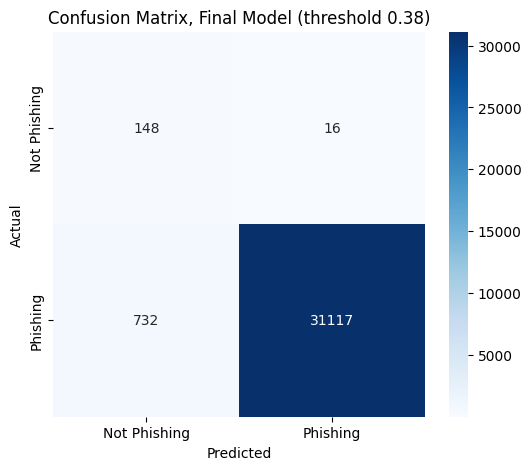

In [ ]:
final_preds = (test_proba >= final_threshold).astype(int)
cm = confusion_matrix(y_test, final_preds, labels=[0, 1])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Phishing", "Phishing"], yticklabels=["Not Phishing", "Phishing"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix, Final Model (threshold {final_threshold:.2f})")
plt.show()

**11. Stability Check (5-Fold Cross-Validation on Training Data)**


A small standard deviation means the result does not depend on one lucky or unlucky split.

In [ ]:
stab = cross_validate(clone(final_model), x_train, y_train, cv=cv5, scoring=scoring, groups=g_train)

for key in ["macro_f1", "benign_recall", "phishing_recall"]:
    s = stab[f"test_{key}"]
    print(f"{key:16s}: {np.round(s, 4)}  mean {s.mean()*100:.2f}% (+/- {s.std()*100:.2f}%)")

macro_f1        : [0.5162 0.5476 0.663  0.6102 0.6164]  mean 59.07% (+/- 5.23%)
benign_recall   : [0.9091 0.9313 0.8626 0.9237 0.9466]  mean 91.46% (+/- 2.87%)
phishing_recall : [0.8996 0.9355 0.9831 0.9697 0.9707]  mean 95.17% (+/- 3.05%)


**12. Feature Importance**

Permutation importance on the test set shows how much performance drops when one feature is shuffled. The model's built-in importance is added when the final model provides it (Random Forest does, Gradient Boosting does not).

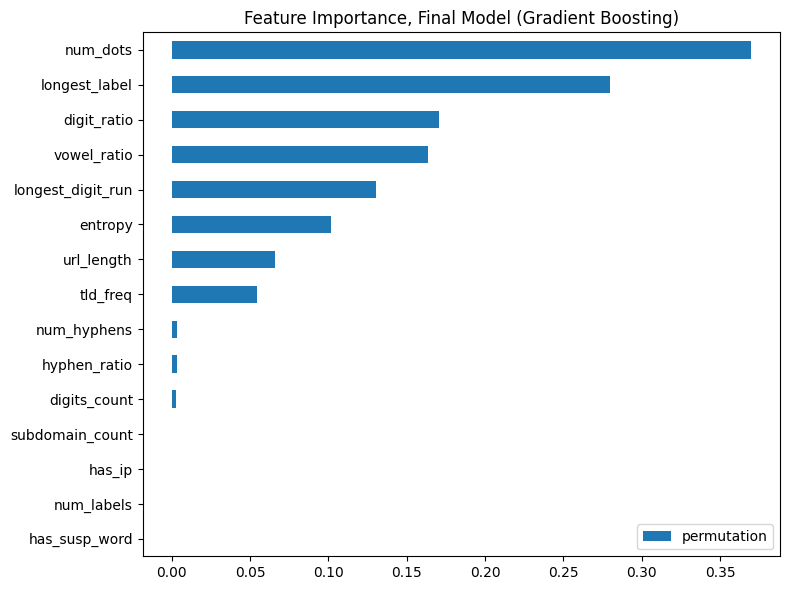

,permutation
num_dots,0.369734
longest_label,0.279632
digit_ratio,0.170628
vowel_ratio,0.163736
longest_digit_run,0.130175
entropy,0.101475
url_length,0.065795
tld_freq,0.054214
num_hyphens,0.003592
hyphen_ratio,0.003589


In [ ]:
perm = permutation_importance(final_model, x_test, y_test, scoring="balanced_accuracy",
                              n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1)

importance_table = pd.DataFrame({"permutation": perm.importances_mean}, index=x_train.columns)
if hasattr(final_model, "feature_importances_"):
    importance_table["built_in"] = final_model.feature_importances_
importance_table = importance_table.sort_values("permutation", ascending=False)

importance_table.plot(kind="barh", figsize=(8, 6))
plt.gca().invert_yaxis()
plt.title(f"Feature Importance, Final Model ({final_name})")
plt.tight_layout()
plt.show()

importance_table

**13. Save the Final Model and Add a Prediction Function**

The saved file bundles everything needed at prediction time: the model, the chosen threshold, the training-set TLD frequency map, and the feature order. predict_url rebuilds the same host-based features for a single raw URL, and a quick check confirms it matches the features used in training.

In [ ]:
FEATURE_ORDER = x_train.columns.tolist()

artifact = {
    "model": final_model,
    "model_name": final_name,
    "threshold": final_threshold,
    "tld_freq_map": tld_freq_map.to_dict(),
    "feature_order": FEATURE_ORDER,
}

def build_row(url, artifact=artifact):
    f = host_features(normalize_host(url))
    row = {c: f[c] for c in feature_cols}
    row["tld_freq"] = artifact["tld_freq_map"].get(f["tld"], 0.0)
    return pd.DataFrame([row])[artifact["feature_order"]]

def predict_url(url, artifact=artifact):
    p = float(artifact["model"].predict_proba(build_row(url, artifact))[0, 1])
    return {"url": url, "phishing_probability": round(p, 4),
            "prediction": "phishing" if p >= artifact["threshold"] else "not phishing"}

# sanity check: rebuilding features from the raw URL must match the test features used in training
check_idx = x_test.sample(300, random_state=RANDOM_STATE).index
mismatches = 0
for idx in check_idx:
    rebuilt = build_row(df.loc[idx, "url"]).iloc[0].astype(float).values
    original = x_test.loc[idx, FEATURE_ORDER].astype(float).values
    if not np.allclose(rebuilt, original):
        mismatches += 1
print("Rows where predict_url features differ from training features:", mismatches)

joblib.dump(artifact, "phishing_model.joblib")
print("Saved: phishing_model.joblib")

for u in ["https://www.google.com/search?q=test",
          "google.com",
          "github.com",
          "http://192.168.10.5/login",
          "http://secure-login-paypal.verify-account.xyz/update"]:
    print(predict_url(u))

Rows where predict_url features differ from training features: 0
Saved: phishing_model.joblib
{'url': 'https://www.google.com/search?q=test', 'phishing_probability': 0.0074, 'prediction': 'not phishing'}
{'url': 'google.com', 'phishing_probability': 0.0074, 'prediction': 'not phishing'}
{'url': 'github.com', 'phishing_probability': 0.6029, 'prediction': 'phishing'}
{'url': 'http://192.168.10.5/login', 'phishing_probability': 1.0, 'prediction': 'phishing'}
{'url': 'http://secure-login-paypal.verify-account.xyz/update', 'phishing_probability': 1.0, 'prediction': 'phishing'}


**14. Notes and Limitations**

- The benign class has only 820 rows (about 164 in the test set), so every benign metric, including false positive rate, has a wide margin of error. One or two test rows can move it by a full percentage point.
- Benign URLs are bare domains and phishing URLs are full URLs, so all features are computed from the host name only. Path, query, and scheme information was removed on purpose (see sections 3 to 3.6).
- Train and test rows never share a registered domain (grouped split in section 5), and the cross-validation folds are grouped the same way. Scores are therefore lower than a random split would give, and closer to what new domains would see. Base domains are found with a simple rule (last two labels, or three for patterns like co.uk), not a full public-suffix list.
- A leading "www." is stripped from every host, since no benign host in the data has one and the model would otherwise learn it as a phishing signal.
- The final threshold is chosen on training data to keep benign recall at or above the target in section 9. Lower the target to catch more phishing, or raise it to flag fewer legitimate sites.
- Results describe how well the model separates this dataset's phishing hosts from this dataset's benign hosts. Real-world performance on other benign sites is not guaranteed. More diverse benign data would be the most useful improvement.
- To use the model elsewhere, load it with joblib.load("phishing_model.joblib"). The saved model needs the host_features, normalize_host and build_row functions from this notebook to score raw URLs.

**15. Conclusion**

- **Final model:** a tuned Random Forest, chosen over Logistic Regression, Naive Bayes, a Decision Tree and Gradient Boosting using cross-validation on training data only.
- **Test results (threshold 0.64):** phishing recall 97.5%, benign recall 89.6%, macro F1 62.6%, ROC-AUC 0.988, benign PR-AUC 0.770. A lower threshold (0.08) reaches a macro F1 of 88.5% but flags about a third of legitimate sites as phishing.
- **What made the evaluation more honest:** class weights instead of undersampling, host-only features, removal of a leading "www.", and a split grouped by domain. A random split would have let 88% of phishing test rows share a domain with training rows.
- **Main weakness:** only 820 legitimate rows, mostly long domain names. Short popular domains such as github.com can score near the decision threshold.